# Full-article reactivity scoring

This notebook applies the reactivity detector to the full cleaned article body from `processed_articles.parquet`, using the headline and summary as additional signals rather than as the only evidence.

The key idea is that the article body is now the primary text source for checking whether the story is describing recent price action, while the headline and summary still carry more weight because they are usually the news hook. We keep article-body matches lower weight than headline matches so that long articles do not dominate the score simply because they contain more words.

### Why this change matters

The earlier version used the headline and summary as the main evidence. That was a useful starting point, but it missed the strongest signal in many cases: the cleaned article text itself. This meant that when the algorithm didn't pick up a reactive article, it was most likely due to the fact that our patterns had missed the key reactive phrase in the headline, and had no way to make up for itself by checking the full article so its score would jsut stay at 0. The full article often makes it clear whether the story is describing a recent stock move or whether it is about the underlying company, management, or fundamentals.

At the same time, long articles are naturally more likely to contain matching phrases. To avoid a false signal, we therefore weight the article body lower than the headline and summary:

- Headline strong hit: 1.0
- Headline weak hit: 0.5
- Summary strong hit: 0.5
- Summary weak hit: 0.25
- Article strong hit: 0.2
- Article weak hit: 0.1

This preserves the headline as the most important signal while allowing the article body to contribute additional, more granular evidence.

### Loading the processed article data

Now that we have the full clean dataset of articles, we can load it here and begin adjusting our reactivity algorithm.

In [13]:
from stock_predictor.config import PROCESSED_DATA_DIR, INTERIM_DATA_DIR
from stock_predictor.text.reactive import classify_reactive, threshold_analysis
import pandas as pd

articles = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
articles[["article_id", "headline", "summary", "processed_body", "timestamp_utc"]].head()

,article_id,headline,summary,processed_body,timestamp_utc
0,138802119,"'I Don't Buy Single Stocks,' Says Dave Ramsey....",,"Steve from Greensboro, North Carolina, called ...",2025-08-31 17:00:00+00:00
1,139021751,Marjorie Taylor Greene Put Money In BlackRock'...,Rep. Marjorie Taylor Greene (R-Ga.) has added ...,Rep. Marjorie Taylor Greene (R-Ga.) has added ...,2025-08-31 14:30:59+00:00
2,138690782,Consumer Tech News (August 25–August 30): Nvid...,Despite a strong quarter from NVIDIA — now the...,Despite a strong quarter from NVIDIA Corporati...,2025-08-31 11:31:32+00:00
3,136581238,Analyst: Tesla (TLSA) Automotive Weakness Weig...,"Tesla, Inc. (NASDAQ:TSLA) is one of the AI Sto...","Oops, something went wrong Tesla, Inc. (NASDAQ...",2025-08-30 14:13:30+00:00
4,136581240,Tesla’s sales down 40% in EU while Chinese EV ...,"""We are in a global competition with China,"" J...","Oops, something went wrong Tesla's future in t...",2025-08-30 10:45:00+00:00


### Example of full-article scoring

We can now compare a headline-only score with the updated score that includes the full article text. Below we create an example and show the difference.

In [14]:
example_headline = "Tesla shares fell 5% after weak guidance"
example_summary = "Analysts said the move reflected a sharp drop in sentiment."
example_article = (
    "Tesla shares fell 5% after the company warned that deliveries would soften. "
    "The article says investors reacted badly and the stock slipped further in after-hours trading."
)

headline_only = classify_reactive(example_headline, example_summary, "", threshold=1.0)
full_article = classify_reactive(example_headline, example_summary, example_article, threshold=1.0)

print("Headline-only:\n", headline_only.score, headline_only.is_reactive, headline_only.hits)
print("With full article:\n", full_article.score, full_article.is_reactive, full_article.hits)

Headline-only:
 1.0 1 ['H! shares fell']
With full article:
 1.5999999999999999 1 ['H! shares fell', 'A! shares fell', 'A! stock slip', 'A? investors reacted', 'A? after-hours trading']


### Updated scoring

To showcase how the updated scoring should add some depth to the feature, rather than most often taking values of 1 or 0, we can run our new algorithm on a smaller sample without labelling. This will just show how the improvements will affect the scoring feature.

In [15]:
#Inspect the scoring behavior on a small sample using the updated classifier
sample = articles.sample(n=30, random_state=13)

sample["score"] = sample.apply(
    lambda row: classify_reactive(
        row.get("headline", ""),
        row.get("summary", ""),
        row.get("processed_body", ""),
        threshold=1.0,
    ).score,
    axis=1,
)

sample[["article_id", "headline", "score"]].sort_values("score", ascending=False).head(10)

,article_id,headline,score
5,136581241,Is Tesla's Stock Price Justified After BYD Sur...,1.6
35,136557719,Tesla's Europe sales crater 40% in July as BYD...,1.5
800,138302984,Tesla Stock Dips as Investors Weigh Its Fourth...,1.5
1239,139928303,Tesla Plans International Expansion of FSD Sof...,0.8
22,136568940,Latest News In Electric Vehicles - Vehicle-To-...,0.4
1367,140456271,Mark Cuban Made More Money Hedging Yahoo Stock...,0.4
170,136915583,Analyst Says He’s Turned Bullish on Tesla (TSL...,0.4
893,139257016,Old Mission Capital Boosts iShares MSCI China ...,0.3
603,137950133,Tesla Stock In Spotlight -- Michael Burry Says...,0.2
1809,141148587,Gary Black Says SpaceX's Volatility Proves He ...,0.1


We can clearly see that there is much more depth in the scoring column, allowing us to more accurately judge the reactivity of an article past just the binary flag. We also see that even though the full article may contain some reactive language, it is still worth keeping unflagged since it is safe to assume that the main focus of the article is on something else, which serves as good quality data for our model.

### Validation against the labelled sample

The next step is to apply the algorithm to our original hand labelled sample. It is worth noting that the dataset has been cleaned and stripped, so some articles from our original sample will have been filtered out of the dataset, meaning we may not have the full 100 articles to work with. However, for the purposes of showing our new algorithm, a smaller sample size is still fine, although we have to accept that our statistics may be a bit off.

In [16]:
labelled_sample = pd.read_csv(INTERIM_DATA_DIR / "labelled_sample.csv")
labelled_sample = labelled_sample[labelled_sample["hand_label"].notna() & (labelled_sample["hand_label"] != "")].copy()
labelled_sample["hand_label"] = labelled_sample["hand_label"].astype(int)

#Load all articles from the processed corpus and filter to labelled IDs
sample_with_labels = articles[articles["article_id"].isin(labelled_sample["article_id"])].copy()

#Compute score for each row with the full article included
sample_with_labels["pred_score"] = sample_with_labels.apply(
    lambda row: classify_reactive(
        row.get("headline", ""),
        row.get("summary", ""),
        row.get("processed_body", ""),
        threshold=1.0,
    ).score,
    axis=1,
)

sample_with_labels["hand_label"] = sample_with_labels["article_id"].map(
    labelled_sample.set_index("article_id")["hand_label"]
)

print(f"Loaded {len(sample_with_labels)} labelled articles for evaluation")
sample_with_labels[["article_id", "hand_label", "pred_score"]].head()

Loaded 66 labelled articles for evaluation


,article_id,hand_label,pred_score
30,136563697,0,0.2
137,138668280,1,0.2
177,136913565,0,0.0
211,138422203,0,0.6
273,137278983,1,1.4


### Tuning our threshold

Now that we have processed our labelled articles, we can use the results to potentially adjust our threshold to make the algorithm work more accurately. We will pick a number of lower and higher thresholds to test on our algorithm and evaluate the results from each one to see whether the threshold needs changing.

In [17]:
# ompare several threshold settings using the original labelled sample
thresholds = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
threshold_df = threshold_analysis(
    INTERIM_DATA_DIR / "labelled_sample.csv",
    sample_with_labels,
    thresholds=thresholds,
    article_column="processed_body",
)

threshold_df

,threshold,agreement,precision,recall,base_rate_pred,base_rate_true,tp,fp,fn,tn
0,0.25,0.40,0.275862,0.615385,0.439394,0.25,8,21,5,32
1,0.50,0.47,0.350000,0.538462,0.303030,0.25,7,13,6,40
2,0.75,0.53,0.500000,0.384615,0.151515,0.25,5,5,8,48
3,1.00,0.55,0.666667,0.307692,0.090909,0.25,4,2,9,51
4,1.25,0.56,1.000000,0.230769,0.045455,0.25,3,0,10,53
5,1.50,0.55,1.000000,0.153846,0.030303,0.25,2,0,11,53
6,2.00,0.54,1.000000,0.076923,0.015152,0.25,1,0,12,53


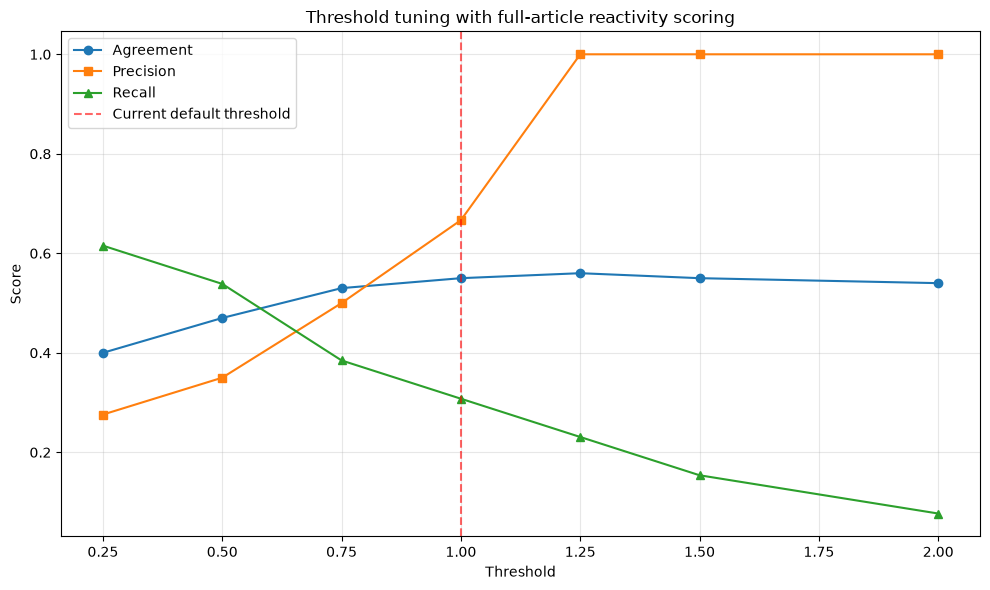

In [18]:
#Plot the threshold sweep
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df["threshold"], threshold_df["agreement"], marker='o', label='Agreement')
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker='s', label='Precision')
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker='^', label='Recall')
ax.axvline(1.0, color='red', linestyle='--', alpha=0.6, label='Current default threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold tuning with full-article reactivity scoring')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

From the plot, it looks like as we increase our threshold we are trading recall for precision, which makes sense since a higher threshold means less false positives but more false negatives. Even though the plot shows a middle point of around 0.6, if we look closer at the amount of false positives and negatives in the table breakdown, it makes more sense to stay with our original threshold since we want to get a better balance of minimising false positives and negatives, and if we increase the threshold further we see the false positives are removed, which we aren't particularly focused on minimising. However, if we go the other way then the number of false positives shoots up drastically which we also ultimately don't want.

### Summary

The full-article version should usually provide a better signal than the headline-only version because it can detect reactive wording in the cleaned article text that the headline may underspecify.

At the same time, we do not want to label every article that mentions a stock move as reactive. This is because an article may mention stock movement but still focus on something else. That is why the body-weighting stays deliberately low and the headline remains as the largest teller of a reactive article.

Now that we have also decided on a threshold, we are ready to take this to the next stage.

With the updated algorithm, we can now proceed to use it as a feature in our model. As said at the end of the [initial reactivity notebook](./1.2-kk-article-further-EDA.ipynb), we can integrate BERTtopic into this at a later stage to improve its performance.